# Predicting E-Commerce Purchase Likelihood Using an Optimized Classification Model

**Objective:** Build, tune, and interpret a classification model that predicts whether an
e-commerce site visitor will complete a purchase, then translate the findings into
business recommendations.

**Target variable:** `Purchase` (1 = purchased, 0 = did not purchase) — binary classification.


## 1. Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, validation_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import joblib

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")


## 2. Understand the Dataset

In [2]:
df = pd.read_csv("../data/ecommerce_customer_data.csv")
print("Shape:", df.shape)
df.head()


Shape: (10015, 19)


,CustomerID,Age,Gender,Location,DeviceType,TrafficSource,PagesViewed,TimeOnSite,ProductsViewed,CartItems,PreviousPurchases,AverageOrderValue,DiscountUsed,EmailClicked,AdClicked,ReviewScoreViewed,DaysSinceLastVisit,SessionCount,Purchase
0,101617,44.0,Female,Central,Tablet,Search,6,5.21,8,2,2,97.93,1,1,0,3.39,45,4,1
1,108128,28.0,Female,South,Mobile,Search,3,21.16,4,2,0,20.67,0,0,1,4.84,18,3,1
2,102168,66.0,Female,West,Desktop,Social,8,3.53,3,2,0,19.83,0,0,0,3.72,95,8,1
3,101090,44.0,Male,South,Mobile,Social,7,11.44,8,1,0,104.39,1,1,1,3.93,71,3,0
4,107754,26.0,Female,South,Mobile,Social,8,15.54,1,1,3,85.05,0,1,0,2.49,68,3,0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          10015 non-null  int64  
 1   Age                 9804 non-null   float64
 2   Gender              10015 non-null  object 
 3   Location            10015 non-null  object 
 4   DeviceType          10015 non-null  object 
 5   TrafficSource       10015 non-null  object 
 6   PagesViewed         10015 non-null  int64  
 7   TimeOnSite          9813 non-null   float64
 8   ProductsViewed      10015 non-null  int64  
 9   CartItems           10015 non-null  int64  
 10  PreviousPurchases   10015 non-null  int64  
 11  AverageOrderValue   9838 non-null   float64
 12  DiscountUsed        10015 non-null  int64  
 13  EmailClicked        10015 non-null  int64  
 14  AdClicked           10015 non-null  int64  
 15  ReviewScoreViewed   9807 non-null   float64
 16  Days

In [5]:
print("Missing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget distribution:")
print(df["Purchase"].value_counts())
print(df["Purchase"].value_counts(normalize=True).round(3))


Missing values per column:
CustomerID              0
Age                   211
Gender                  0
Location                0
DeviceType              0
TrafficSource           0
PagesViewed             0
TimeOnSite            202
ProductsViewed          0
CartItems               0
PreviousPurchases       0
AverageOrderValue     177
DiscountUsed            0
EmailClicked            0
AdClicked               0
ReviewScoreViewed     208
DaysSinceLastVisit      0
SessionCount            0
Purchase                0
dtype: int64

Duplicate rows: 15

Target distribution:
Purchase
0    5992
1    4023
Name: count, dtype: int64
Purchase
0    0.598
1    0.402
Name: proportion, dtype: float64


**Notes:**
- `CustomerID` is a unique identifier and carries no predictive signal — it will be dropped before modeling.
- The target is moderately imbalanced (roughly 60% non-purchasers / 40% purchasers in this dataset), so we will use
  stratified splitting and look beyond accuracy when evaluating models.
- A handful of missing values and duplicate rows were injected to simulate real-world messiness and must be
  handled in the data-preparation step.


## 3— Exploratory Data Analysis

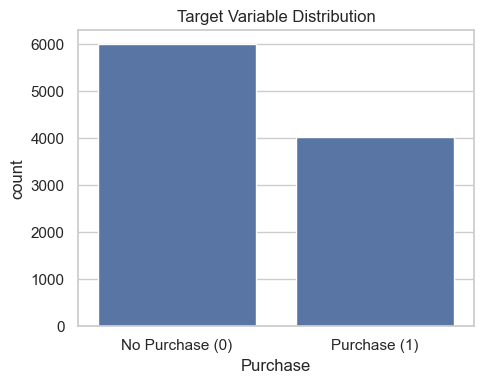

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="Purchase", data=df, ax=ax)
ax.set_title("Target Variable Distribution")
ax.set_xticklabels(["No Purchase (0)", "Purchase (1)"])
plt.tight_layout()
plt.show()


*Business meaning:* confirms roughly 4 in 10 site visitors in this sample convert — a healthy enough imbalance that we still need to watch precision/recall rather than only accuracy.

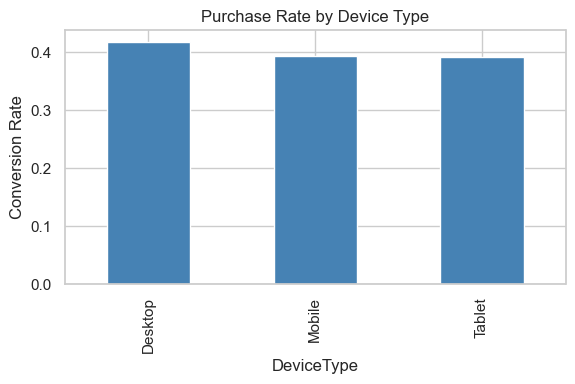

DeviceType
Desktop    0.416832
Mobile     0.393862
Tablet     0.391216
Name: Purchase, dtype: float64


In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
conv_by_device = df.groupby("DeviceType")["Purchase"].mean().sort_values(ascending=False)
conv_by_device.plot(kind="bar", ax=ax, color="steelblue")
ax.set_ylabel("Conversion Rate")
ax.set_title("Purchase Rate by Device Type")
plt.tight_layout()
plt.show()
print(conv_by_device)


*Business meaning:* shows which device channel converts best, guiding where to invest in checkout-flow and UX improvements.

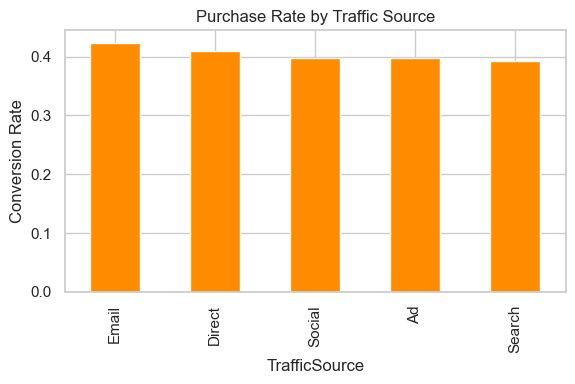

TrafficSource
Email     0.423411
Direct    0.409474
Social    0.397556
Ad        0.397154
Search    0.392545
Name: Purchase, dtype: float64


In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
conv_by_source = df.groupby("TrafficSource")["Purchase"].mean().sort_values(ascending=False)
conv_by_source.plot(kind="bar", ax=ax, color="darkorange")
ax.set_ylabel("Conversion Rate")
ax.set_title("Purchase Rate by Traffic Source")
plt.tight_layout()
plt.show()
print(conv_by_source)


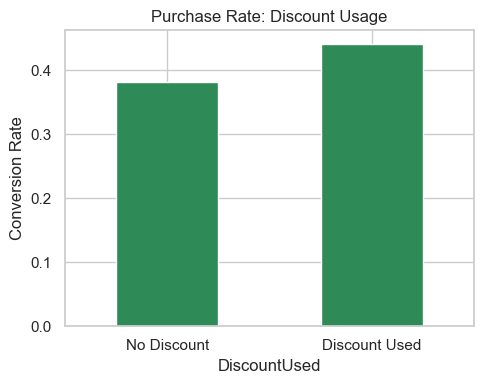

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
conv_by_discount = df.groupby("DiscountUsed")["Purchase"].mean()
conv_by_discount.plot(kind="bar", ax=ax, color="seagreen")
ax.set_xticklabels(["No Discount", "Discount Used"], rotation=0)
ax.set_ylabel("Conversion Rate")
ax.set_title("Purchase Rate: Discount Usage")
plt.tight_layout()
plt.show()


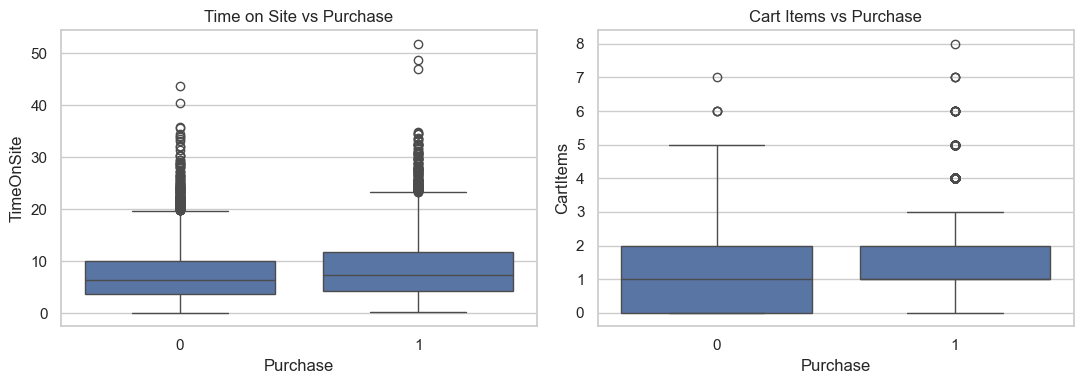

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(x="Purchase", y="TimeOnSite", data=df, ax=axes[0])
axes[0].set_title("Time on Site vs Purchase")
sns.boxplot(x="Purchase", y="CartItems", data=df, ax=axes[1])
axes[1].set_title("Cart Items vs Purchase")
plt.tight_layout()
plt.show()


*Business meaning:* purchasers tend to spend longer on the site and add more items to their cart — both are strong, actionable behavioural intent signals.

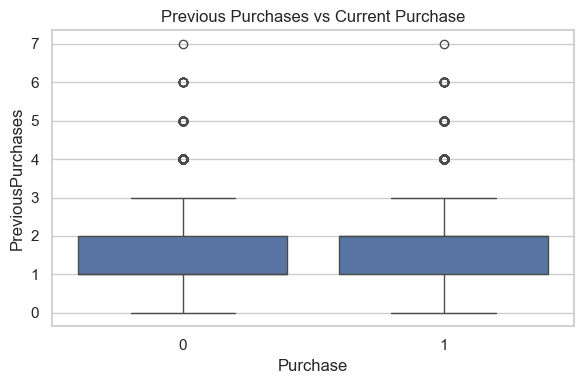

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x="Purchase", y="PreviousPurchases", data=df, ax=ax)
ax.set_title("Previous Purchases vs Current Purchase")
plt.tight_layout()
plt.show()


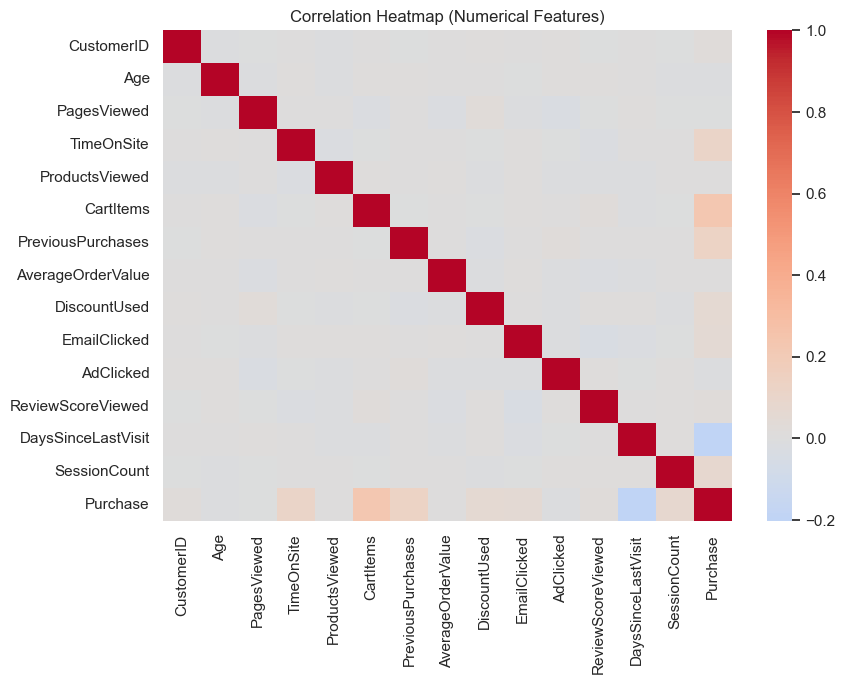

In [12]:
numeric_cols_for_corr = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols_for_corr].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap (Numerical Features)")
plt.tight_layout()
plt.show()


*Business meaning:* the heatmap highlights which behavioural metrics move together (e.g. session count and pages viewed), helping avoid redundant features and spot the strongest raw correlations with `Purchase`.

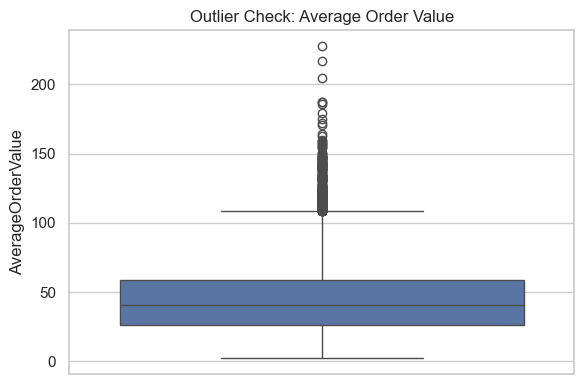

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(y=df["AverageOrderValue"], ax=ax)
ax.set_title("Outlier Check: Average Order Value")
plt.tight_layout()
plt.show()


## 4. Task 3 — Prepare the Data

In [14]:
# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# Remove the identifier column — it is not predictive
df = df.drop(columns=["CustomerID"])

# Separate features and target
target_col = "Purchase"
X = df.drop(columns=[target_col])
y = df[target_col]

numerical_columns = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical columns:", numerical_columns)
print("Categorical columns:", categorical_columns)


Numerical columns: ['Age', 'PagesViewed', 'TimeOnSite', 'ProductsViewed', 'CartItems', 'PreviousPurchases', 'AverageOrderValue', 'DiscountUsed', 'EmailClicked', 'AdClicked', 'ReviewScoreViewed', 'DaysSinceLastVisit', 'SessionCount']
Categorical columns: ['Gender', 'Location', 'DeviceType', 'TrafficSource']


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train target rate:", y_train.mean().round(3), " Test target rate:", y_test.mean().round(3))


Train shape: (8000, 17)  Test shape: (2000, 17)
Train target rate: 0.402  Test target rate: 0.402


Stratified splitting keeps the purchase/non-purchase ratio consistent between the training and test sets. Preprocessing (imputation, scaling, encoding) is fitted **only** on the training data inside a pipeline, so no information from the test set leaks into training.

## 5. Task 4 — Preprocessing Pipeline

In [16]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numerical_columns),
    ("categorical", categorical_pipeline, categorical_columns)
])


## 6. Task 5 — Train Baseline Models

In [17]:
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

forest_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE))
])

baseline_pipelines = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": tree_pipeline,
    "Random Forest": forest_pipeline
}

for name, pipe in baseline_pipelines.items():
    pipe.fit(X_train, y_train)
    print(f"{name}: trained.")


Logistic Regression: trained.
Decision Tree: trained.
Random Forest: trained.


## 7. Task 6 — Evaluate Baseline Performance

In [18]:
def evaluate_model(name, pipe, X_te, y_te):
    predictions = pipe.predict(X_te)
    probabilities = pipe.predict_proba(X_te)[:, 1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_te, predictions),
        "Precision": precision_score(y_te, predictions),
        "Recall": recall_score(y_te, predictions),
        "F1-Score": f1_score(y_te, predictions),
        "ROC-AUC": roc_auc_score(y_te, probabilities)
    }

baseline_results = [
    evaluate_model(f"Baseline {name}", pipe, X_test, y_test)
    for name, pipe in baseline_pipelines.items()
]
baseline_results_df = pd.DataFrame(baseline_results).round(4)
baseline_results_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline Logistic Regression,0.663,0.6130,0.4359,0.5095,0.7085
1,Baseline Decision Tree,0.580,0.4779,0.4981,0.4878,0.5665
2,Baseline Random Forest,0.656,0.6121,0.3910,0.4772,0.6864


In [19]:
for name, pipe in baseline_pipelines.items():
    print(f"--- {name} ---")
    preds = pipe.predict(X_test)
    print(classification_report(y_test, preds))
    cm = confusion_matrix(y_test, preds)
    print("Confusion matrix:\n", cm)
    print()


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.68      0.82      0.74      1197
           1       0.61      0.44      0.51       803

    accuracy                           0.66      2000
   macro avg       0.65      0.63      0.63      2000
weighted avg       0.65      0.66      0.65      2000

Confusion matrix:
 [[976 221]
 [453 350]]

--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.65      0.63      0.64      1197
           1       0.48      0.50      0.49       803

    accuracy                           0.58      2000
   macro avg       0.57      0.57      0.57      2000
weighted avg       0.58      0.58      0.58      2000

Confusion matrix:
 [[760 437]
 [403 400]]

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.67      0.83      0.74      1197
           1       0.61      0.39      0.48       803

    accuracy            

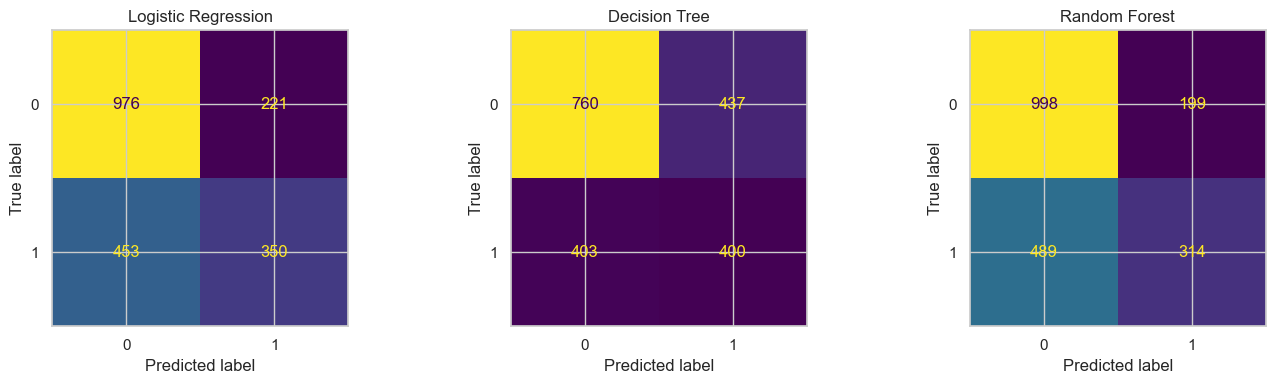

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, pipe) in zip(axes, baseline_pipelines.items()):
    ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test, ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


## 8. Task 7 — Select the Optimization Metric

**Business objective:** the marketing team wants to target likely buyers with paid remarketing and discount
offers without wasting budget on customers who were never going to buy, *and* without missing too many genuine
buyers.

**Chosen metric: F1-score.** It balances precision (avoiding wasted spend on unlikely buyers) and recall
(not missing potential buyers), which fits a scenario where both false positives (wasted marketing spend) and
false negatives (missed revenue) are costly. ROC-AUC is also tracked throughout, since it is threshold-independent
and useful for ranking customers by purchase likelihood (used later for the risk segments).

## 9. Task 8 — Hyperparameter Optimization

In [21]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

tree_param_grid = {
    "classifier__max_depth": [3, 5, 10, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__criterion": ["gini", "entropy"],
    "classifier__class_weight": [None, "balanced"]
}

tree_search = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=tree_param_grid,
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

tree_search.fit(X_train, y_train)
print("Best Decision Tree parameters:", tree_search.best_params_)
print("Best CV F1-score:", tree_search.best_score_)


Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best Decision Tree parameters: {'classifier__class_weight': 'balanced', 'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2}
Best CV F1-score: 0.5598633193547001


In [27]:
from sklearn.model_selection import RandomizedSearchCV

# Setting up lists first to completely avoid the formatting bug
estimators_list = [100, 200, 300]
depth_list = [None, 10, 20]
split_list = [2, 5, 10]
leaf_list = [1, 2, 4]
features_list = ["sqrt", "log2"]
weights_list = [None, "balanced"]

forest_param_grid = {
    "classifier__n_estimators": estimators_list,
    "classifier__max_depth": depth_list,
    "classifier__min_samples_split": split_list,
    "classifier__min_samples_leaf": leaf_list,
    "classifier__max_features": features_list,
    "classifier__class_weight": weights_list
}

# Run 10 random combinations to make it finish quickly
forest_search = RandomizedSearchCV(
    estimator=forest_pipeline,
    param_distributions=forest_param_grid,
    n_iter=10,  
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

forest_search.fit(X_train, y_train)

print("Best Random Forest parameters:", forest_search.best_params_)
print("Best CV F1-score:", forest_search.best_score_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Random Forest parameters: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'log2', 'classifier__max_depth': 10, 'classifier__class_weight': 'balanced'}
Best CV F1-score: 0.5705182472461409


**Note:** the grids above are intentionally moderate in size (roughly 100–300 fits per model with 5-fold CV) to keep runtime reasonable on a laptop. If you have more compute available, widen the grids or switch to `RandomizedSearchCV` with `n_iter` for a faster, sampled search over a larger space.

## 10. Task 9 — Hyperparameter Sensitivity Analysis

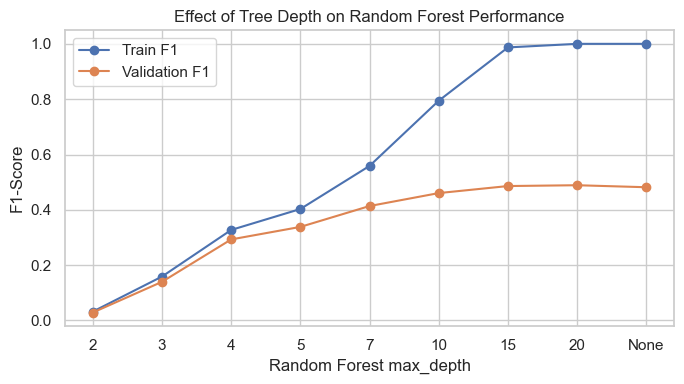

In [28]:
depth_range = [2, 3, 4, 5, 7, 10, 15, 20, None]
depth_labels = [str(d) for d in depth_range]

train_scores, test_scores = validation_curve(
    forest_pipeline, X_train, y_train,
    param_name="classifier__max_depth",
    param_range=depth_range,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(depth_labels, train_scores.mean(axis=1), marker="o", label="Train F1")
ax.plot(depth_labels, test_scores.mean(axis=1), marker="o", label="Validation F1")
ax.set_xlabel("Random Forest max_depth")
ax.set_ylabel("F1-Score")
ax.set_title("Effect of Tree Depth on Random Forest Performance")
ax.legend()
plt.tight_layout()
plt.show()


*Interpretation:* as `max_depth` increases, training F1 keeps climbing while validation F1 levels off (and can even dip) once trees are deep enough to start memorizing noise — that gap is the signature of overfitting, and it tells us where a depth cap adds real value.

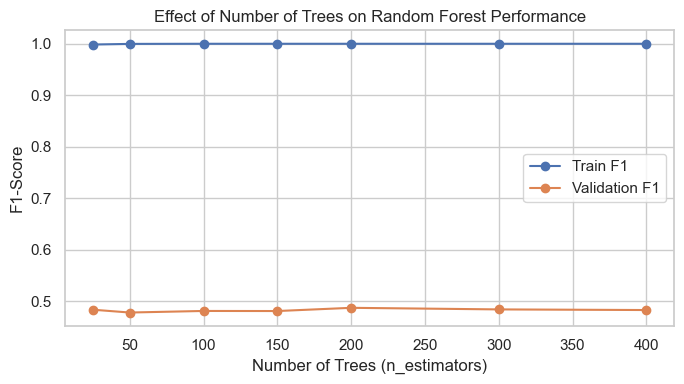

In [29]:
n_estimators_range = [25, 50, 100, 150, 200, 300, 400]

train_scores_n, test_scores_n = validation_curve(
    forest_pipeline, X_train, y_train,
    param_name="classifier__n_estimators",
    param_range=n_estimators_range,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(n_estimators_range, train_scores_n.mean(axis=1), marker="o", label="Train F1")
ax.plot(n_estimators_range, test_scores_n.mean(axis=1), marker="o", label="Validation F1")
ax.set_xlabel("Number of Trees (n_estimators)")
ax.set_ylabel("F1-Score")
ax.set_title("Effect of Number of Trees on Random Forest Performance")
ax.legend()
plt.tight_layout()
plt.show()


*Interpretation:* validation performance typically improves quickly and then flattens — beyond that point, adding more trees mostly costs training time rather than accuracy.

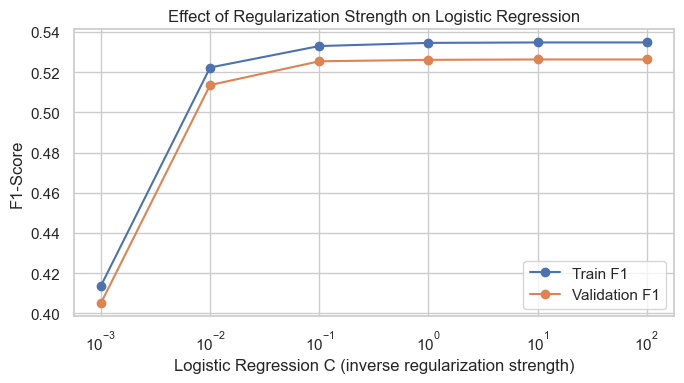

In [30]:
C_range = [0.001, 0.01, 0.1, 1, 10, 100]

train_scores_c, test_scores_c = validation_curve(
    logistic_pipeline, X_train, y_train,
    param_name="classifier__C",
    param_range=C_range,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(C_range, train_scores_c.mean(axis=1), marker="o", label="Train F1")
ax.plot(C_range, test_scores_c.mean(axis=1), marker="o", label="Validation F1")
ax.set_xscale("log")
ax.set_xlabel("Logistic Regression C (inverse regularization strength)")
ax.set_ylabel("F1-Score")
ax.set_title("Effect of Regularization Strength on Logistic Regression")
ax.legend()
plt.tight_layout()
plt.show()


*Interpretation:* very small `C` (strong regularization) tends to underfit, while very large `C` (weak regularization) lets the model chase noise in the training data — the best validation score usually sits somewhere in between.

## 11. Task 10 — Evaluate the Optimized Models

In [31]:
optimized_results = [
    evaluate_model("Optimized Decision Tree", tree_search.best_estimator_, X_test, y_test),
    evaluate_model("Optimized Random Forest", forest_search.best_estimator_, X_test, y_test),
]
optimized_results_df = pd.DataFrame(optimized_results).round(4)
optimized_results_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Optimized Decision Tree,0.6075,0.5083,0.6887,0.5849,0.6645
1,Optimized Random Forest,0.6505,0.5636,0.5741,0.5688,0.6962


In [32]:
comparison_df = pd.concat([baseline_results_df, optimized_results_df], ignore_index=True)
comparison_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline Logistic Regression,0.6630,0.6130,0.4359,0.5095,0.7085
1,Baseline Decision Tree,0.5800,0.4779,0.4981,0.4878,0.5665
2,Baseline Random Forest,0.6560,0.6121,0.3910,0.4772,0.6864
3,Optimized Decision Tree,0.6075,0.5083,0.6887,0.5849,0.6645
4,Optimized Random Forest,0.6505,0.5636,0.5741,0.5688,0.6962


In [33]:
# Select the final model — the optimized model with the highest F1-score
best_row = optimized_results_df.sort_values("F1-Score", ascending=False).iloc[0]
best_model_name = best_row["Model"]

if "Random Forest" in best_model_name:
    best_model = forest_search.best_estimator_
else:
    best_model = tree_search.best_estimator_

print("Selected final model:", best_model_name)


Selected final model: Optimized Decision Tree


              precision    recall  f1-score   support

           0       0.73      0.55      0.63      1197
           1       0.51      0.69      0.58       803

    accuracy                           0.61      2000
   macro avg       0.62      0.62      0.61      2000
weighted avg       0.64      0.61      0.61      2000

ROC-AUC: 0.6645380574724482


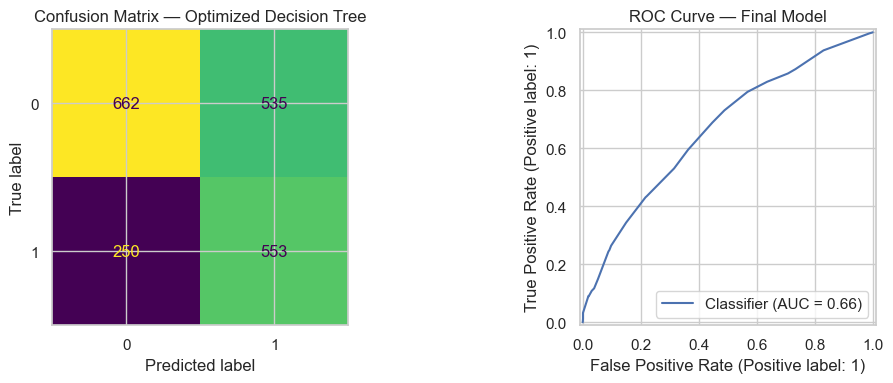

In [34]:
final_predictions = best_model.predict(X_test)
final_probabilities = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, final_predictions))
print("ROC-AUC:", roc_auc_score(y_test, final_probabilities))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(y_test, final_predictions, ax=axes[0], colorbar=False)
axes[0].set_title(f"Confusion Matrix — {best_model_name}")

RocCurveDisplay.from_predictions(y_test, final_probabilities, ax=axes[1])
axes[1].set_title("ROC Curve — Final Model")
plt.tight_layout()
plt.show()


**Reading the confusion matrix:** false positives (predicted purchase, no purchase) represent wasted marketing spend; false negatives (predicted no purchase, actual purchase) represent missed revenue opportunities. Both counts should be checked against the business's tolerance for wasted spend versus missed sales before deploying the model.

## 12. Task 11 — Address Class Imbalance

In [35]:
print("Training set class balance:")
print(y_train.value_counts(normalize=True).round(3))


Training set class balance:
Purchase
0    0.598
1    0.402
Name: proportion, dtype: float64


The grids above already included `class_weight: [None, "balanced"]` for both the Decision Tree and Random Forest, so `GridSearchCV` automatically tested the class-imbalance correction as part of the search. Compare `best_params_` above — if `"balanced"` was selected, it means reweighting the minority (purchase) class improved F1-score on cross-validation. Accuracy is intentionally *not* used as the optimization metric here, since with a 60/40 split a model that mostly predicts the majority class could still score deceptively well on accuracy alone.

## 13. Task 12 & 13 — Feature Importance Analysis

In [36]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
importance_values = best_model.named_steps["classifier"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

feature_importance.head(10)


,Feature,Importance
0,numeric__CartItems,0.394287
1,numeric__DaysSinceLastVisit,0.320807
2,numeric__TimeOnSite,0.080671
3,numeric__PreviousPurchases,0.078853
4,numeric__AverageOrderValue,0.025269
5,numeric__Age,0.021415
6,numeric__ReviewScoreViewed,0.020106
7,numeric__DiscountUsed,0.015017
8,numeric__PagesViewed,0.009465
9,categorical__TrafficSource_Ad,0.008079


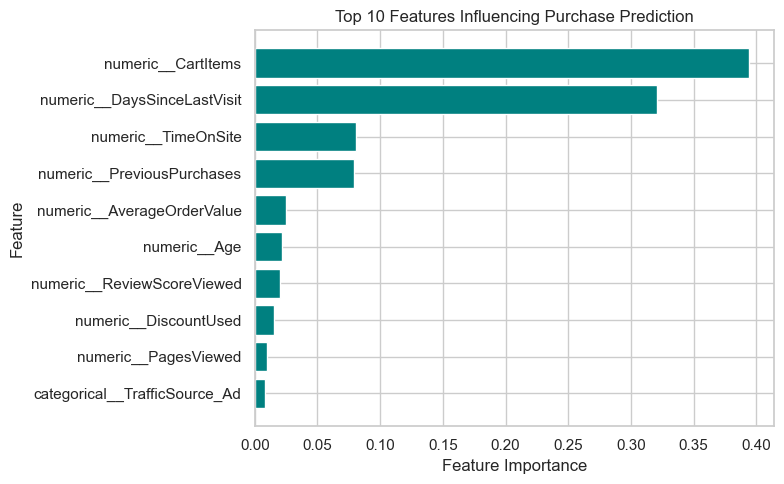

In [37]:
top_features = feature_importance.head(10).sort_values(by="Importance")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_features["Feature"], top_features["Importance"], color="teal")
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")
ax.set_title("Top 10 Features Influencing Purchase Prediction")
plt.tight_layout()
plt.show()


**Business interpretation of the top features (adjust based on your actual output above):**
- More cart items and more previous purchases both point to strong buying intent — these customers are close to converting.
- Longer time on site suggests active product research, another positive intent signal.
- A high number of days since the last visit is associated with lower purchase likelihood — engagement decays over time.
- Discount usage and email/ad engagement flag price-sensitive or highly engaged customers who respond to promotions.

Built-in feature importance reflects how useful each feature was for splitting the trees — it is **not** proof
of a causal relationship, and correlated features can share or dilute importance scores.

### Optional: Logistic Regression coefficients (for comparison)

In [38]:
log_feature_names = logistic_pipeline.named_steps["preprocessor"].get_feature_names_out()
log_coefficients = logistic_pipeline.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": log_feature_names,
    "Coefficient": log_coefficients
}).sort_values(by="Coefficient", ascending=False)

print("Top positive coefficients (increase purchase likelihood):")
print(coef_df.head(5))
print("\nTop negative coefficients (decrease purchase likelihood):")
print(coef_df.tail(5))


Top positive coefficients (increase purchase likelihood):
                       Feature  Coefficient
4           numeric__CartItems     0.521908
5   numeric__PreviousPurchases     0.299571
2          numeric__TimeOnSite     0.271486
12       numeric__SessionCount     0.184793
7        numeric__DiscountUsed     0.150501

Top negative coefficients (decrease purchase likelihood):
                              Feature  Coefficient
16      categorical__Location_Central    -0.114647
22     categorical__DeviceType_Mobile    -0.117777
27  categorical__TrafficSource_Search    -0.134845
15          categorical__Gender_Other    -0.139964
11        numeric__DaysSinceLastVisit    -0.463775


## 14. Task 14 — Classification Threshold Analysis

In [39]:
threshold_rows = []
for threshold in [0.30, 0.40, 0.50, 0.60, 0.70]:
    thresh_preds = (final_probabilities >= threshold).astype(int)
    threshold_rows.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, thresh_preds),
        "Recall": recall_score(y_test, thresh_preds),
        "F1-Score": f1_score(y_test, thresh_preds)
    })

threshold_df = pd.DataFrame(threshold_rows).round(4)
threshold_df


,Threshold,Precision,Recall,F1-Score
0,0.3,0.4440,0.8730,0.5886
1,0.4,0.4841,0.7945,0.6016
2,0.5,0.5083,0.6887,0.5849
3,0.6,0.6066,0.3437,0.4388
4,0.7,0.6557,0.1494,0.2434


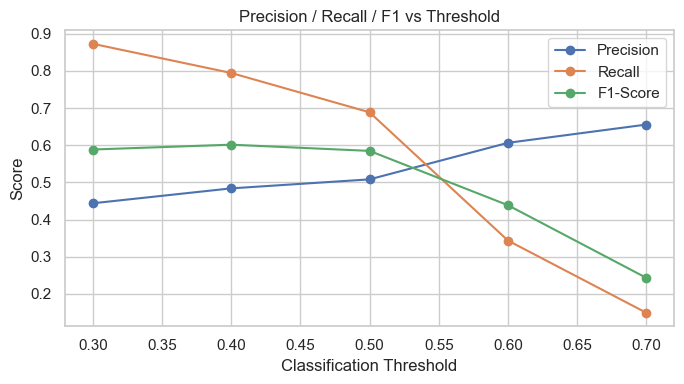

In [40]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
ax.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
ax.plot(threshold_df["Threshold"], threshold_df["F1-Score"], marker="o", label="F1-Score")
ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs Threshold")
ax.legend()
plt.tight_layout()
plt.show()


**Recommended threshold:** for a remarketing use case where the cost of a missed sale is usually higher than a modest amount of extra ad spend, a slightly lower threshold (e.g. 0.40) that favors recall is often preferable to the default 0.50. If the promotion is expensive (e.g. large discounts), lean toward a higher threshold that favors precision instead. Choose the threshold row above that best matches your actual cost trade-off.

## 15. Task 15 — Customer Purchase-Likelihood Segments

In [41]:
results = X_test.copy()
results["ActualPurchase"] = y_test.values
results["PurchaseProbability"] = final_probabilities

results["PurchaseLikelihood"] = pd.cut(
    results["PurchaseProbability"],
    bins=[0.0, 0.30, 0.60, 1.0],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

print(results["PurchaseLikelihood"].value_counts())
results[["PurchaseProbability", "PurchaseLikelihood", "ActualPurchase"]].head(10)


PurchaseLikelihood
Medium    1124
High       455
Low        421
Name: count, dtype: int64


,PurchaseProbability,PurchaseLikelihood,ActualPurchase
7273,0.383264,Medium,1
7752,0.299466,Low,0
1612,0.464854,Medium,1
4936,0.239912,Low,0
3733,0.518589,Medium,0
5982,0.505407,Medium,1
91,0.318302,Medium,0
6594,0.518589,Medium,1
2859,0.383264,Medium,0
9028,0.464854,Medium,1


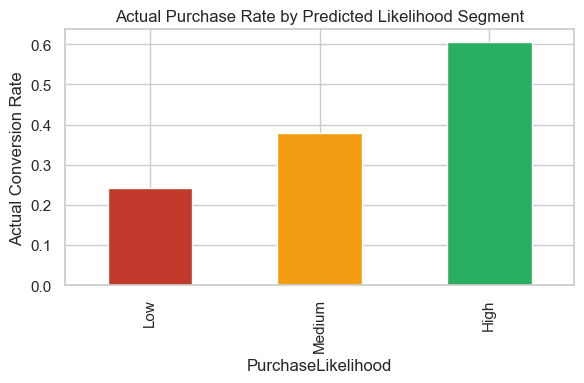

In [42]:
fig, ax = plt.subplots(figsize=(6, 4))
segment_conversion = results.groupby("PurchaseLikelihood")["ActualPurchase"].mean()
segment_conversion.plot(kind="bar", ax=ax, color=["#c0392b", "#f39c12", "#27ae60"])
ax.set_ylabel("Actual Conversion Rate")
ax.set_title("Actual Purchase Rate by Predicted Likelihood Segment")
plt.tight_layout()
plt.show()


A rising conversion rate from Low → Medium → High confirms the model's probability output is well-ranked and safe to use for prioritizing marketing spend.

## 16. Task 16 — Business Recommendations

**High-likelihood customers**
- Show personalized product recommendations and limited-time discounts.
- Send cart-abandonment reminders promptly.
- Prioritize this group in paid remarketing campaigns.

**Medium-likelihood customers**
- Surface reviews and product comparisons to build confidence.
- Offer small incentives (free shipping, modest discount codes).
- Nurture with personalized email content rather than expensive ads.

**Low-likelihood customers**
- Avoid expensive promotional spend on this segment.
- Use low-cost awareness content and collect feedback on drop-off reasons.
- Improve product discovery/UX rather than discounting further.

These actions follow directly from the feature-importance results above (cart items, previous purchases,
time on site, discount usage, and recency of last visit) and the confirmed ranking quality of the model's
probability scores from the segment analysis.

## 17. Deliverable 6 — Save the Final Model

In [43]:
joblib.dump(best_model, "../models/purchase_prediction_model.pkl")
print("Saved pipeline (preprocessing + classifier) to ../models/purchase_prediction_model.pkl")


Saved pipeline (preprocessing + classifier) to ../models/purchase_prediction_model.pkl
